# Deep Learning Assignment 1


- Data is loaded from a local `data/` folder.
- Figures are saved into an `outputs/` folder with informative filenames.
- Cells are ordered so dependencies are explicit and minimal.

In [2]:
%matplotlib inline

from pathlib import Path
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples
import pickle
import gc
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Resolve the working directory for this notebook and find the local data folder.
notebook_dir = Path.cwd()
if not (notebook_dir / "data").exists() and (notebook_dir / "deep_learning_ass1" / "data").exists():
    notebook_dir = notebook_dir / "deep_learning_ass1"

DATA_ROOT = notebook_dir / "data"
OUTPUTS_DIR = notebook_dir / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

print("Notebook directory:", notebook_dir)
print("Data root:", DATA_ROOT)
print("Outputs directory:", OUTPUTS_DIR)

if not DATA_ROOT.exists():
    raise FileNotFoundError(f"Expected data directory not found: {DATA_ROOT}")

if not (DATA_ROOT / "cifar-10-batches-py").exists():
    raise FileNotFoundError(f"Expected CIFAR-10 batch folder not found in {DATA_ROOT}")

Using device: cuda
Notebook directory: /home/raveco/deep_learning_ass1
Data root: /home/raveco/deep_learning_ass1/data
Outputs directory: /home/raveco/deep_learning_ass1/outputs


In [3]:
def get_train_val_test_data(validation_size=5000,
                            train_transforms=transforms.ToTensor(),
                            test_transforms=transforms.ToTensor()):
    """
    Load the CIFAR10 dataset and split it into training, validation, and test sets.

    Parameters:
        validation_size (int): Number of samples to use for the validation set.
        train_transforms: Transformations to be applied to the training data.
        test_transforms: Transformations to be applied to the validation and test data.
    """

    # load the training set twice:
    # one copy with train transforms, one copy with test/validation transforms
    full_train_dataset = datasets.CIFAR10(
        root=str(DATA_ROOT),
        train=True,
        download=False,
        transform=train_transforms
    )

    full_val_dataset = datasets.CIFAR10(
        root=str(DATA_ROOT),
        train=True,
        download=False,
        transform=test_transforms
    )

    test_dataset = datasets.CIFAR10(
        root=str(DATA_ROOT),
        train=False,
        download=False,
        transform=test_transforms
    )

    total_train_size = len(full_train_dataset)
    train_size = total_train_size - validation_size

    indices = torch.randperm(total_train_size).tolist()

    train_indices = indices[:train_size]
    val_indices = indices[train_size:]

    train_dataset = Subset(full_train_dataset, train_indices)
    val_dataset = Subset(full_val_dataset, val_indices)

    return train_dataset, val_dataset, test_dataset

In [4]:
train_dataset, val_dataset, test_dataset = get_train_val_test_data()
print("Loaded datasets:")
print("  Train images:", len(train_dataset))
print("  Validation images:", len(val_dataset))
print("  Test images:", len(test_dataset))

/home/raveco/.conda/envs/neuro_dl/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Loaded datasets:
  Train images: 45000
  Validation images: 5000
  Test images: 10000


In [5]:
def save_figure(fig, filename):
    """Save a matplotlib figure to the outputs directory."""
    output_path = OUTPUTS_DIR / filename
    fig.savefig(output_path, bbox_inches="tight")
    print(f"Saved figure: {output_path}")
    return output_path

def show_images(dataset, num_images=5, title=""): #shows images from the dataset
    """Display sample images from the dataset."""
    label_names = dataset.dataset.classes if hasattr(dataset, "dataset") else dataset.classes

    fig, axes = plt.subplots(1, num_images, figsize=(10, 3))
    fig.suptitle(title)

    for i in range(num_images):
        image, label = dataset[i]
        image = image.permute(1, 2, 0).numpy()

        ax = axes[i] if num_images > 1 else axes
        ax.imshow(image)
        ax.set_title(label_names[label])
        ax.axis("off")

    fig.tight_layout()
    return fig

Saved figure: /home/raveco/deep_learning_ass1/outputs/train_samples.png


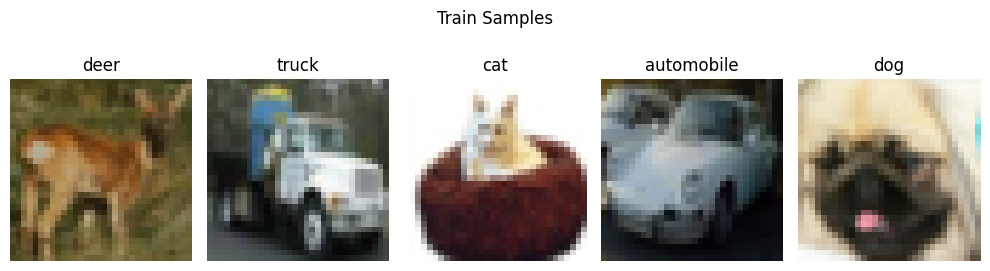

Saved figure: /home/raveco/deep_learning_ass1/outputs/validation_samples.png


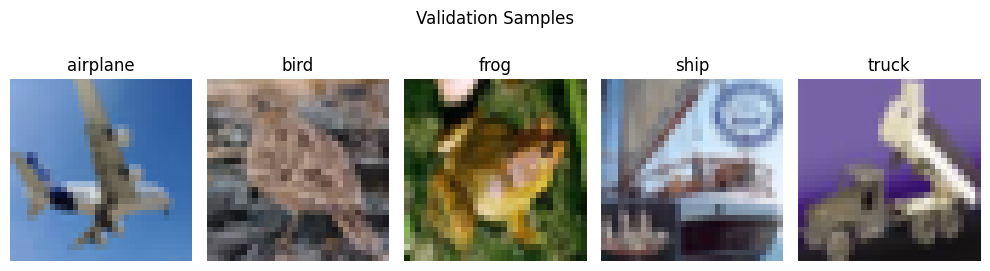

Saved figure: /home/raveco/deep_learning_ass1/outputs/test_samples.png


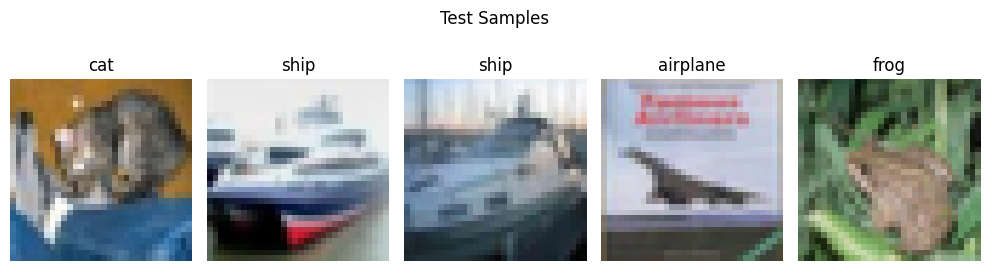

In [6]:
fig = show_images(train_dataset, 5, title="Train Samples")
save_figure(fig, "train_samples.png")
plt.show()

fig = show_images(val_dataset, 5, title="Validation Samples")
save_figure(fig, "validation_samples.png")
plt.show()

fig = show_images(test_dataset, 5, title="Test Samples")
save_figure(fig, "test_samples.png")
plt.show()

Image shape (C, H, W): torch.Size([3, 32, 32])
Label: 4

Channel-wise stats:
Red channel -> min: 0.0000, max: 0.8431, mean: 0.2333
Green channel -> min: 0.0078, max: 0.7922, mean: 0.1951
Blue channel -> min: 0.0000, max: 0.6549, mean: 0.1154
Saved figure: /home/raveco/deep_learning_ass1/outputs/debug_rgb_channels.png


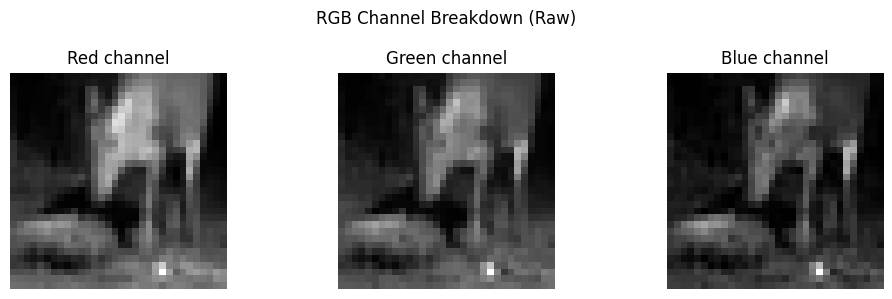

Final image array shape (H, W, C): (32, 32, 3)
Value range: 0.0 to 0.84313726
Saved figure: /home/raveco/deep_learning_ass1/outputs/debug_rgb_overlay.png


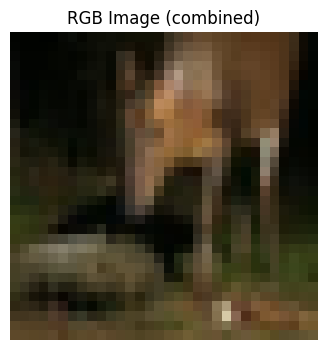

In [7]:
# ===================== DEBUG: IMAGE RGB CHECK =====================

def debug_image_rgb(dataset):
    """Debug: show individual RGB channels and statistics."""
    image, label = dataset[0]  # take first image

    print("Image shape (C, H, W):", image.shape)
    print("Label:", label)

    print("\nChannel-wise stats:")
    for i, color in enumerate(["Red", "Green", "Blue"]):
        print(f"{color} channel -> min: {image[i].min():.4f}, max: {image[i].max():.4f}, mean: {image[i].mean():.4f}")

    # show raw channels
    fig, axs = plt.subplots(1, 3, figsize=(10, 3))
    for i, color in enumerate(["Red", "Green", "Blue"]):
        axs[i].imshow(image[i], cmap="gray")
        axs[i].set_title(f"{color} channel")
        axs[i].axis("off")

    fig.suptitle("RGB Channel Breakdown (Raw)")
    fig.tight_layout()
    return fig


def debug_rgb_overlay(dataset):
    """Debug: show RGB image overlay."""
    image, _ = dataset[0]

    # convert CHW → HWC for display
    img = image.permute(1, 2, 0).numpy()

    fig = plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title("RGB Image (combined)")
    plt.axis("off")

    print("Final image array shape (H, W, C):", img.shape)
    print("Value range:", img.min(), "to", img.max())
    
    return fig


# run debug
train_dataset, val_dataset, test_dataset = get_train_val_test_data()
fig_rgb = debug_image_rgb(train_dataset)
save_figure(fig_rgb, "debug_rgb_channels.png")
plt.show()

fig_overlay = debug_rgb_overlay(train_dataset)
save_figure(fig_overlay, "debug_rgb_overlay.png")
plt.show()

# ================================================================

Saved figure: /home/raveco/deep_learning_ass1/outputs/class_distribution_train_val_test.png


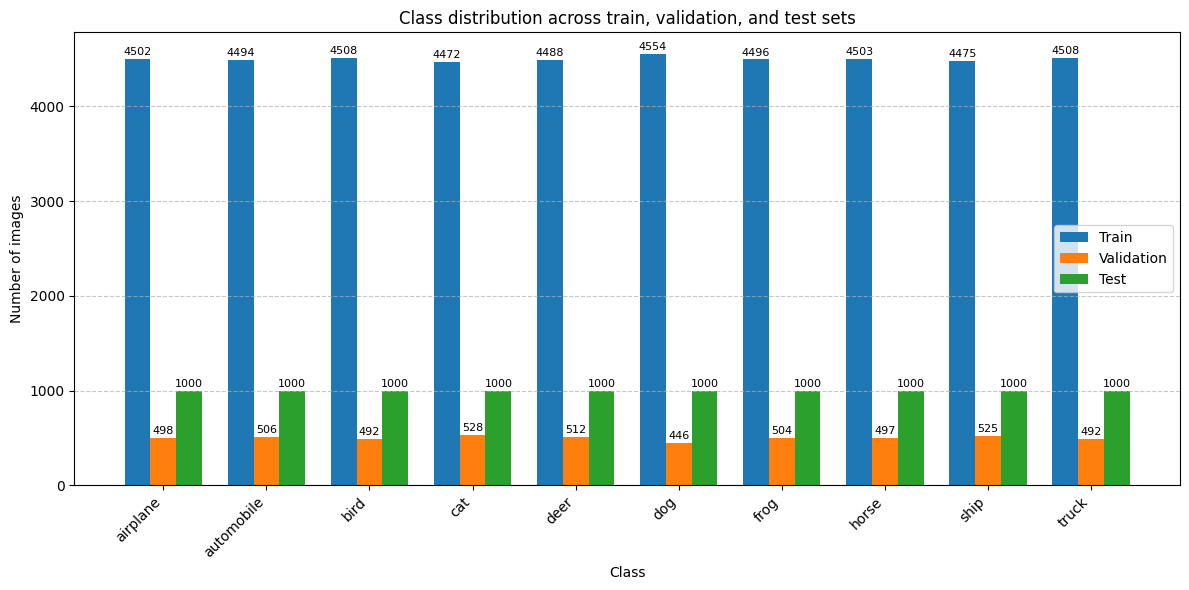

In [8]:
# ===================== PLOT CLASS DISTRIBUTION =====================

def plot_class_distribution(train_dataset, val_dataset, test_dataset):
    """Plot class distribution across train, validation, and test sets."""
    label_names = test_dataset.classes
    num_classes = len(label_names)

    train_counts = np.zeros(num_classes, dtype=int)
    val_counts = np.zeros(num_classes, dtype=int)
    test_counts = np.zeros(num_classes, dtype=int)

    # count train labels
    for idx in train_dataset.indices:
        label = train_dataset.dataset.targets[idx]
        train_counts[label] += 1

    # count validation labels
    for idx in val_dataset.indices:
        label = val_dataset.dataset.targets[idx]
        val_counts[label] += 1

    # count test labels
    for label in test_dataset.targets:
        test_counts[label] += 1

    x = np.arange(num_classes)
    bar_width = 0.25

    fig, ax = plt.subplots(figsize=(12, 6))

    bars_train = ax.bar(x - bar_width, train_counts, width=bar_width, label="Train")
    bars_val = ax.bar(x, val_counts, width=bar_width, label="Validation")
    bars_test = ax.bar(x + bar_width, test_counts, width=bar_width, label="Test")

    # add numbers on top of bars
    def add_labels(bars):
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height + 20,
                str(int(height)),
                ha='center',
                va='bottom',
                fontsize=8
            )

    add_labels(bars_train)
    add_labels(bars_val)
    add_labels(bars_test)

    ax.set_xticks(x)
    ax.set_xticklabels(label_names, rotation=45, ha='right')
    ax.set_ylabel("Number of images")
    ax.set_xlabel("Class")
    ax.set_title("Class distribution across train, validation, and test sets")

    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend()
    fig.tight_layout()
    
    return fig

train_dataset, val_dataset, test_dataset = get_train_val_test_data()
fig_dist = plot_class_distribution(train_dataset, val_dataset, test_dataset)
save_figure(fig_dist, "class_distribution_train_val_test.png")
plt.show()

Saved figure: /home/raveco/deep_learning_ass1/outputs/rgb_stats_per_class.png


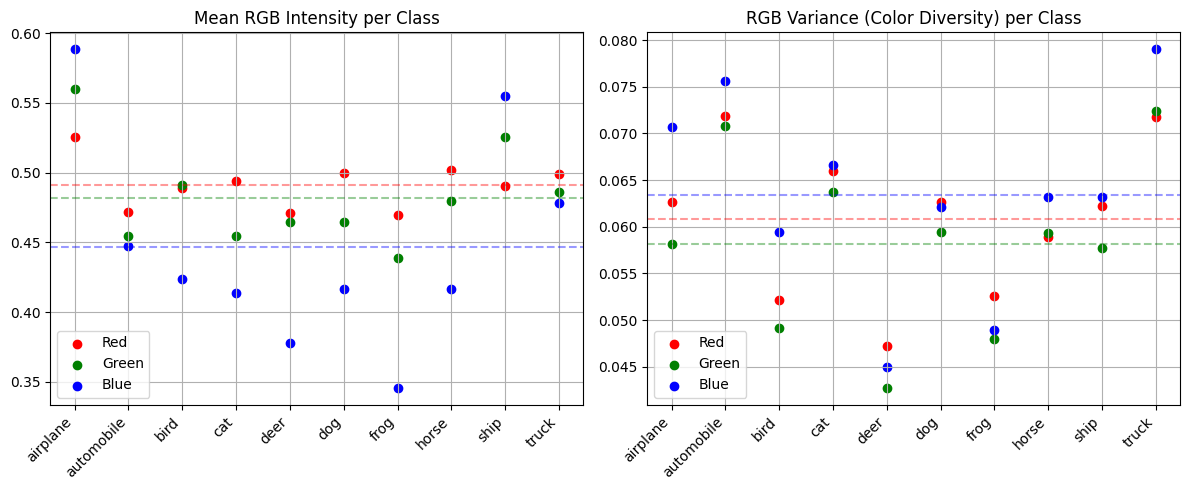

airplane:
  Mean RGB     = [0.52575165 0.5598887  0.58850604]
  Variance RGB = [0.06266639 0.05813658 0.07066157]

automobile:
  Mean RGB     = [0.47150448 0.45476502 0.44725356]
  Variance RGB = [0.07190898 0.07078549 0.07567225]

bird:
  Mean RGB     = [0.48930612 0.49088752 0.42373613]
  Variance RGB = [0.05214761 0.04920031 0.05944683]

cat:
  Mean RGB     = [0.49406824 0.45500177 0.4138288 ]
  Variance RGB = [0.06600912 0.06367742 0.0666212 ]

deer:
  Mean RGB     = [0.4713086  0.4650322  0.37804878]
  Variance RGB = [0.04721141 0.04272385 0.04493545]

dog:
  Mean RGB     = [0.49979466 0.46474704 0.4167153 ]
  Variance RGB = [0.06264068 0.05947785 0.06211033]

frog:
  Mean RGB     = [0.4697883  0.4387865  0.34573323]
  Variance RGB = [0.05253343 0.04798228 0.04889154]

horse:
  Mean RGB     = [0.50198025 0.47995657 0.41697493]
  Variance RGB = [0.0589098  0.05938292 0.06322955]

ship:
  Mean RGB     = [0.49053803 0.5257339  0.5552711 ]
  Variance RGB = [0.06227103 0.05776179 0.063

In [9]:
# ===================== RGB CLASS ANALYSIS =====================

def compute_class_rgb_stats(dataset):
    """
    Computes per-class RGB mean and variance.

    Args:
        dataset: torch.utils.data.Subset (train/val)

    Returns:
        class_means: (num_classes, 3)
        class_vars: (num_classes, 3)
    """
    num_classes = len(dataset.dataset.classes)

    pixel_sum = torch.zeros(num_classes, 3)
    pixel_sq_sum = torch.zeros(num_classes, 3)
    pixel_count = torch.zeros(num_classes)

    for idx in dataset.indices:
        img, label = dataset.dataset[idx]  # (C,H,W)

        img = img.view(3, -1)  # flatten → (3, pixels)

        pixel_sum[label] += img.sum(dim=1)
        pixel_sq_sum[label] += (img ** 2).sum(dim=1)
        pixel_count[label] += img.shape[1]

    class_means = pixel_sum / pixel_count.unsqueeze(1)
    class_vars = (pixel_sq_sum / pixel_count.unsqueeze(1)) - class_means**2

    return class_means.numpy(), class_vars.numpy()


def plot_rgb_stats(class_means, class_vars, class_names):
    """Plot RGB statistics (mean and variance) per class."""
    x = np.arange(len(class_names))
    mean_R = class_means[:, 0].mean()
    mean_G = class_means[:, 1].mean()
    mean_B = class_means[:, 2].mean()

    var_R = class_vars[:, 0].mean()
    var_G = class_vars[:, 1].mean()
    var_B = class_vars[:, 2].mean()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # ---- Mean ----
    axes[0].scatter(x, class_means[:, 0], color='r', label="Red")
    axes[0].scatter(x, class_means[:, 1], color='g', label="Green")
    axes[0].scatter(x, class_means[:, 2], color='b', label="Blue")
    axes[0].set_title("Mean RGB Intensity per Class")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(class_names, rotation=45, ha='right')
    axes[0].legend()
    axes[0].grid(True)

    axes[0].axhline(mean_R, color='r', linestyle='--', alpha=0.4)
    axes[0].axhline(mean_G, color='g', linestyle='--', alpha=0.4)
    axes[0].axhline(mean_B, color='b', linestyle='--', alpha=0.4)

    # ---- Variance ----
    axes[1].scatter(x, class_vars[:, 0], color='r', label="Red")
    axes[1].scatter(x, class_vars[:, 1], color='g', label="Green")
    axes[1].scatter(x, class_vars[:, 2], color='b', label="Blue")
    axes[1].set_title("RGB Variance (Color Diversity) per Class")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(class_names, rotation=45, ha='right')
    axes[1].legend()
    axes[1].grid(True)

    axes[1].axhline(var_R, color='r', linestyle='--', alpha=0.4)
    axes[1].axhline(var_G, color='g', linestyle='--', alpha=0.4)
    axes[1].axhline(var_B, color='b', linestyle='--', alpha=0.4)

    fig.tight_layout()
    return fig


# ---- RUN ANALYSIS ----
class_means, class_vars = compute_class_rgb_stats(train_dataset)
fig_rgb_stats = plot_rgb_stats(class_means, class_vars, train_dataset.dataset.classes)
save_figure(fig_rgb_stats, "rgb_stats_per_class.png")
plt.show()

# Optional: print numeric values (useful for report)
for i, cls in enumerate(train_dataset.dataset.classes):
    print(f"{cls}:")
    print(f"  Mean RGB     = {class_means[i]}")
    print(f"  Variance RGB = {class_vars[i]}")
    print()

# =============================================================

Saved figure: /home/raveco/deep_learning_ass1/outputs/pca_with_silhouette_table.png


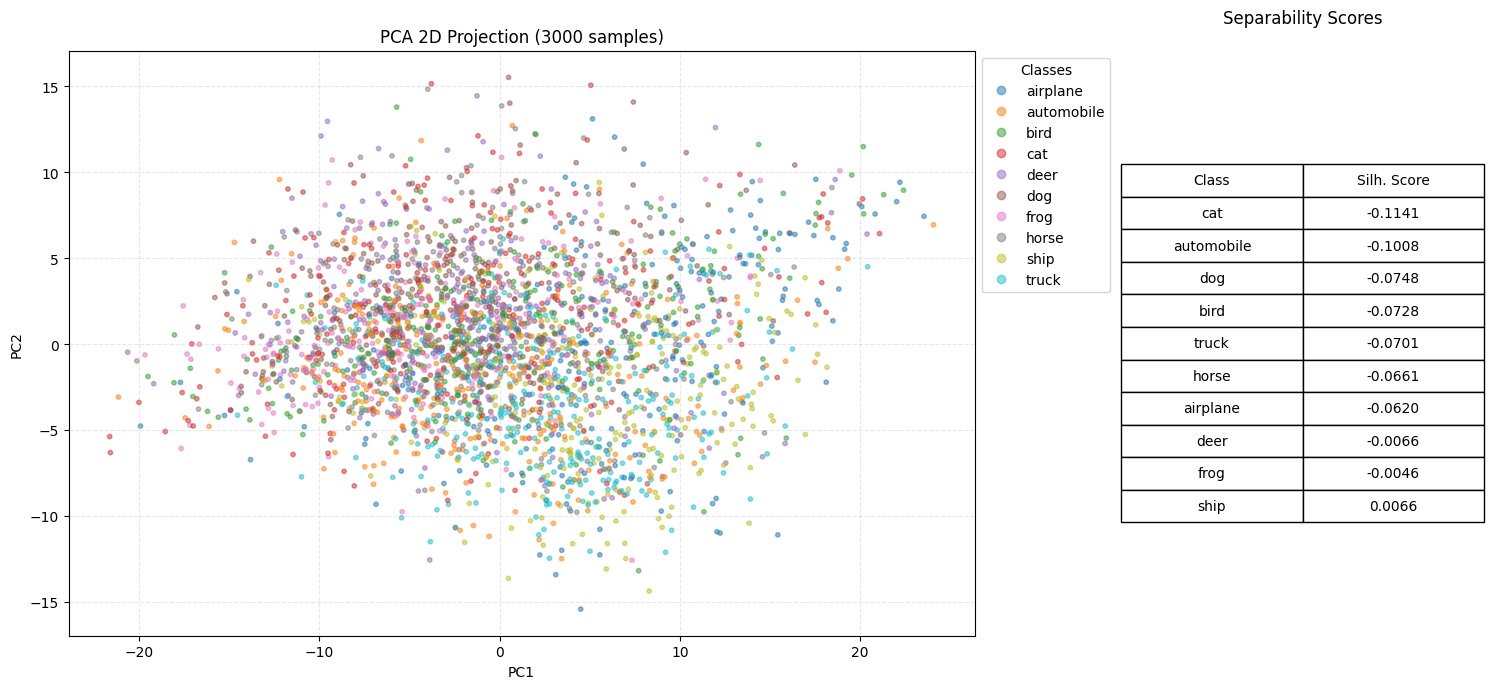

In [10]:
def plot_combined_analysis(dataset, num_samples=3000):
    """
    Computes PCA and Silhouette scores together and plots them side-by-side.
    """
    # 1. Prepare Data
    images, labels = [], []
    indices = dataset.indices[:num_samples]
    for idx in indices:
        img, lbl = dataset.dataset[idx]
        images.append(img.view(-1).numpy())
        labels.append(lbl)
    
    images = np.array(images)
    labels = np.array(labels)
    class_names = dataset.dataset.classes

    # 2. Compute PCA
    pca = PCA(n_components=2)
    projected = pca.fit_transform(images)

    # 3. Compute Silhouette Scores
    sample_scores = silhouette_samples(images, labels)
    class_scores = []
    for i in range(len(class_names)):
        avg_score = np.mean(sample_scores[labels == i])
        class_scores.append([class_names[i], f"{avg_score:.4f}"])
    
    # Sort table by score (lowest to highest) for the plot
    class_scores.sort(key=lambda x: float(x[1]))

    # 4. Plotting
    # Create a figure with extra width for the table
    fig, (ax_plot, ax_table) = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={'width_ratios': [3, 1]})

    # Scatter Plot
    scatter = ax_plot.scatter(projected[:, 0], projected[:, 1], c=labels, cmap='tab10', alpha=0.5, s=10)
    handles, _ = scatter.legend_elements()
    ax_plot.legend(handles, class_names, title="Classes", loc="upper left", bbox_to_anchor=(1, 1))
    ax_plot.set_title(f"PCA 2D Projection ({num_samples} samples)")
    ax_plot.set_xlabel("PC1")
    ax_plot.set_ylabel("PC2")
    ax_plot.grid(True, linestyle='--', alpha=0.3)

    # Table Plot
    ax_table.axis('off')
    table = ax_table.table(
        cellText=class_scores, 
        colLabels=["Class", "Silh. Score"], 
        loc='center',
        cellLoc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.8) # Adjust scaling for readability
    ax_table.set_title("Separability Scores", pad=20)

    fig.tight_layout()
    return fig

# Run the combined analysis
fig_combined = plot_combined_analysis(train_dataset, num_samples=3000)
save_figure(fig_combined, "pca_with_silhouette_table.png")
plt.show()

In [11]:
def train(model, optimizer, loss_fn, train_loader, val_loader=None, epochs=10, device="cuda", scheduler=None):
    model.to(device)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    
    for epoch in range(epochs):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total_train += labels.size(0)
            correct_train += predicted.eq(labels).sum().item()
        
        # Step the scheduler at the end of every epoch if provided
        if scheduler is not None:
            scheduler.step()
            
        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct_train / total_train
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        if val_loader:
            model.eval()
            val_running_loss, correct_val, total_val = 0.0, 0, 0
            with torch.no_grad():
                for v_in, v_lab in val_loader:
                    v_in, v_lab = v_in.to(device), v_lab.to(device)
                    v_out = model(v_in)
                    val_running_loss += loss_fn(v_out, v_lab).item() * v_in.size(0)
                    _, v_pred = v_out.max(1)
                    total_val += v_lab.size(0)
                    correct_val += v_pred.eq(v_lab).sum().item()
            
            history["val_loss"].append(val_running_loss / len(val_loader.dataset))
            history["val_acc"].append(correct_val / total_val)
            
    return history


def test(model, test_loader, loss_fn, device="cuda"):
    """
    Evaluate the trained model on the test dataset.

    Parameters:
        model: The trained model to evaluate.
        test_loader: DataLoader providing the test data in batches.
        loss_fn: The loss function used to compute the test loss.
        device (str): Device for computation (e.g., "cuda" or "cpu").

    Returns:
        average_loss: Average loss on the test set.
        accuracy: Classification accuracy on the test set.
    """
    model.to(device)
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            
            test_loss += loss.item() * inputs.size(0)
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    average_loss = test_loss / len(test_loader.dataset)
    accuracy = correct / total
    
    return average_loss, accuracy

## Model Definitions

The following cells contain commented-out model architectures that can be uncommented and used as needed.

In [12]:
class VanillaMLP(nn.Module):
    def __init__(self, input_size=3072, hidden_dims=[512, 256], num_classes=10, activation_name='relu'):
        super(VanillaMLP, self).__init__()
        
        # Map strings to activation functions
        acts = {'relu': nn.ReLU(), 'tanh': nn.Tanh(), 'sigmoid': nn.Sigmoid()}
        activation = acts.get(activation_name.lower(), nn.ReLU())
        
        layers = []
        prev_dim = input_size
        for dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, dim))
            layers.append(activation)
            prev_dim = dim
        
        layers.append(nn.Linear(prev_dim, num_classes))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1) # Flatten (B, 3, 32, 32) -> (B, 3072)
        return self.model(x)

# --- THE INITIALIZATION FUNCTION (Implemented outside the class) ---
def init_weights(model, init_type='kaiming'):
    def init_func(m):
        if isinstance(m, nn.Linear):
            if init_type == 'kaiming':
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif init_type == 'xavier':
                nn.init.xavier_normal_(m.weight)
            
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
    model.apply(init_func)

In [13]:
# %%
# Define experiments to run
experiments = [
    # Baseline
    {"name": "Exp1_Base", "hidden_dims": [512, 256], "lr": 0.001, "batch_size": 64, "activation": "relu", "optimizer": "adam", "init": "kaiming", "epochs": 15},
    
    # Architecture Variations
    {"name": "Exp2_Deep", "hidden_dims": [1024, 512, 256, 128], "lr": 0.001, "batch_size": 64, "activation": "relu", "optimizer": "adam", "init": "kaiming", "epochs": 15},
    {"name": "Exp3_Narrow", "hidden_dims": [128, 64], "lr": 0.001, "batch_size": 64, "activation": "relu", "optimizer": "adam", "init": "kaiming", "epochs": 15},
    {"name": "Exp4_Medium", "hidden_dims": [256, 128], "lr": 0.001, "batch_size": 64, "activation": "relu", "optimizer": "adam", "init": "kaiming", "epochs": 15},
    {"name": "Exp5_Wide", "hidden_dims": [1024, 1024], "lr": 0.001, "batch_size": 64, "activation": "relu", "optimizer": "adam", "init": "kaiming", "epochs": 15},
    
    # Hyperparameter Variations
    {"name": "Exp6_Batch32", "hidden_dims": [512, 256], "lr": 0.001, "batch_size": 32, "activation": "relu", "optimizer": "adam", "init": "kaiming", "epochs": 15},
    
    # Activation & Initialization
    {"name": "Exp7_Tanh_Xavier", "hidden_dims": [512, 256], "lr": 0.001, "batch_size": 64, "activation": "tanh", "optimizer": "adam", "init": "xavier", "epochs": 15},
    {"name": "Exp8_Sigmoid_Xavier", "hidden_dims": [512, 256], "lr": 0.001, "batch_size": 64, "activation": "sigmoid", "optimizer": "adam", "init": "xavier", "epochs": 15},
    
    # Optimizer & Scheduler
    {"name": "Exp9_SGD", "hidden_dims": [512, 256], "lr": 0.01, "batch_size": 64, "activation": "relu", "optimizer": "sgd", "init": "kaiming", "epochs": 15},
    {"name": "Exp10_SGD_Momentum", "hidden_dims": [512, 256], "lr": 0.01, "batch_size": 64, "activation": "relu", "optimizer": "sgd_momentum", "init": "kaiming", "epochs": 15},
    {"name": "Exp11_Adam_StepLR", "hidden_dims": [512, 256], "lr": 0.001, "batch_size": 64, "activation": "relu", "optimizer": "adam", "init": "kaiming", "scheduler": "step", "epochs": 15},
    
    # Long Training Variation (20 Epochs)
    {"name": "Exp12_LongTrain", "hidden_dims": [512, 256], "lr": 0.001, "batch_size": 64, "activation": "relu", "optimizer": "adam", "init": "kaiming", "epochs": 20},
]

In [14]:
# Assuming OUTPUTS_DIR is already defined as a Path object
MODEL_SAVE_DIR = OUTPUTS_DIR / "models"
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Weights will be saved to: {MODEL_SAVE_DIR}")

Weights will be saved to: /home/raveco/deep_learning_ass1/outputs/models


In [15]:
# --- PRE-LOOP: Load existing results if they exist ---
RESULTS_FILE = "mlp_experiments_results.pkl"
try:
    with open(RESULTS_FILE, "rb") as f:
        results_log = pickle.load(f)
    print(f"✅ Loaded existing results for {len(results_log)} experiments.")
except FileNotFoundError:
    results_log = {}
    print("info: No existing results found. Starting fresh.")

for exp in experiments:
    # --- NEW: SKIP LOGIC ---
    if exp['name'] in results_log:
        print(f"⏩ Skipping {exp['name']}: Result already found in {RESULTS_FILE}")
        continue
        
    print(f"\n{'='*50}")
    print(f"RUNNING EXPERIMENT: {exp['name']}")
    print(f"Target Epochs: {exp['epochs']}")
    print(f"{'='*50}")
    
    # 1. GPU Memory Cleanup
    gc.collect()
    torch.cuda.empty_cache()
    
    # 2. Data Preparation
    train_loader = DataLoader(train_dataset, batch_size=exp['batch_size'], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=exp['batch_size'], shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=exp['batch_size'], shuffle=False)
    
    # 3. Model Instantiation
    model = VanillaMLP(
        hidden_dims=exp['hidden_dims'], 
        activation_name=exp.get('activation', 'relu')
    ).to(device)

    # 4. Weight Initialization
    init_weights(model, init_type=exp.get('init', 'kaiming'))

    # 5. Optimizer Selection
    opt_name = exp.get('optimizer', 'adam')
    if opt_name == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=exp['lr'])
    elif opt_name == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=exp['lr'])
    elif opt_name == 'sgd_momentum':
        optimizer = torch.optim.SGD(model.parameters(), lr=exp['lr'], momentum=0.9)

    # 6. Scheduler Selection
    scheduler = None
    if exp.get('scheduler') == 'step':
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    loss_fn = nn.CrossEntropyLoss()
    
    # 7. Training
    history = train(
        model=model, 
        optimizer=optimizer, 
        loss_fn=loss_fn,
        train_loader=train_loader, 
        val_loader=val_loader,
        epochs=exp['epochs'], 
        device=device,
        scheduler=scheduler
    )
    
    # 8. MANUALLY SAVE MODEL WEIGHTS
    model_filename = f"{exp['name']}_weights.pth"
    model_path = MODEL_SAVE_DIR / model_filename
    torch.save(model.state_dict(), model_path)
    
    # 9. IMMEDIATE TEST EVALUATION
    model.eval()
    test_correct = 0
    test_total = 0
    test_running_loss = 0.0
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            
            test_running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            test_total += targets.size(0)
            test_correct += predicted.eq(targets).sum().item()
            
    final_test_acc = test_correct / test_total
    final_test_loss = test_running_loss / test_total
    
    # 10. Log results and update Pickle
    results_log[exp['name']] = {
        "history": history, 
        "config": exp,
        "test_acc": final_test_acc,
        "test_loss": final_test_loss,
        "model_path": str(model_path)
    }
    
    print(f"\n>>> {exp['name']} Result: Test Acc: {final_test_acc:.4f}, Test Loss: {final_test_loss:.4f}")
    
    # Save the dictionary after every experiment to prevent data loss
    with open(RESULTS_FILE, "wb") as f:
        pickle.dump(results_log, f)

print("\n✅ All pending experiments complete. Weights and logs are saved in the outputs directory.")

✅ Loaded existing results for 13 experiments.
⏩ Skipping Exp1_Base: Result already found in mlp_experiments_results.pkl
⏩ Skipping Exp2_Deep: Result already found in mlp_experiments_results.pkl
⏩ Skipping Exp3_Narrow: Result already found in mlp_experiments_results.pkl
⏩ Skipping Exp4_Medium: Result already found in mlp_experiments_results.pkl
⏩ Skipping Exp5_Wide: Result already found in mlp_experiments_results.pkl
⏩ Skipping Exp6_Batch32: Result already found in mlp_experiments_results.pkl
⏩ Skipping Exp7_Tanh_Xavier: Result already found in mlp_experiments_results.pkl
⏩ Skipping Exp8_Sigmoid_Xavier: Result already found in mlp_experiments_results.pkl
⏩ Skipping Exp9_SGD: Result already found in mlp_experiments_results.pkl
⏩ Skipping Exp10_SGD_Momentum: Result already found in mlp_experiments_results.pkl
⏩ Skipping Exp11_Adam_StepLR: Result already found in mlp_experiments_results.pkl
⏩ Skipping Exp12_LongTrain: Result already found in mlp_experiments_results.pkl

✅ All pending exper

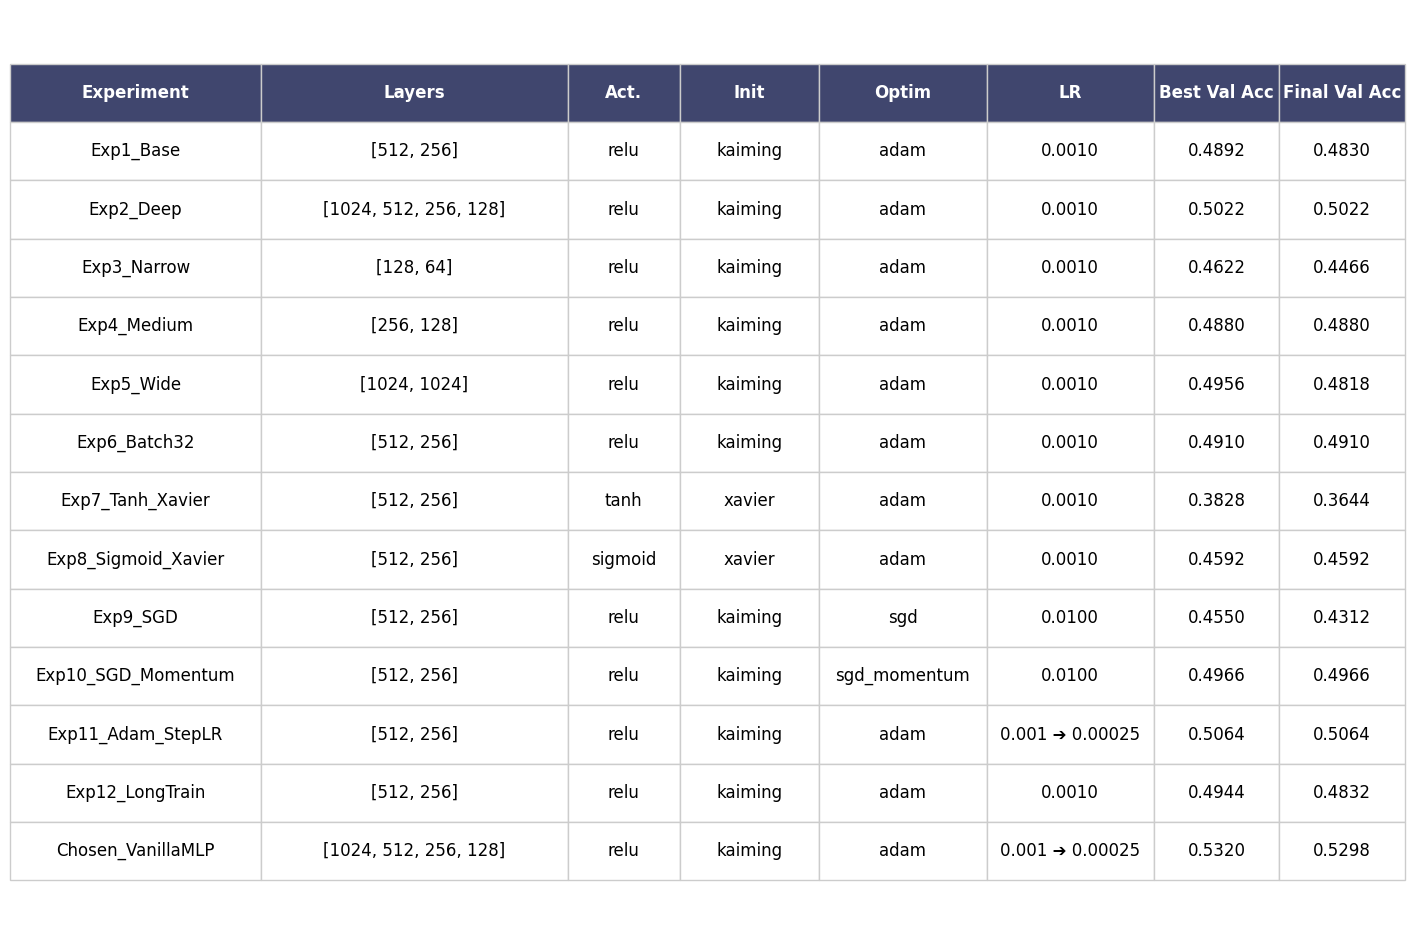

✅ Coherent alignment fixed. Table saved to: outputs/summary_table.png


In [16]:
def save_results_as_image(results_dict, outputs_dir="outputs", filename="summary_table.png"):
    if not results_dict:
        print("Error: The results_log is empty. Run experiments first!")
        return

    # 1. Process Data
    summary_list = []
    for name, data in results_dict.items():
        h = data['history']
        conf = data['config']
        
        # LR Display Logic
        if conf.get('scheduler') == 'step':
            lr_display = f"{conf['lr']} ➔ 0.00025"
        else:
            lr_display = f"{conf['lr']:.4f}"

        summary_list.append({
            "Experiment": name,
            "Layers": str(conf['hidden_dims']),
            "Act.": conf['activation'],
            "Init": conf['init'],
            "Optim": conf['optimizer'],
            "LR": lr_display,
            "Best Val Acc": f"{max(h['val_acc']):.4f}",
            "Final Val Acc": f"{h['val_acc'][-1]:.4f}"
        })
    
    df = pd.DataFrame(summary_list)

    # 2. Optimized Plotting with Custom Alignment
    fig, ax = plt.subplots(figsize=(18, 12)) # Wider canvas
    ax.axis('off') 
    
    header_color = "#40466e" 
    
    # We define column widths manually to prevent crowding
    # Total should roughly equal 1.0
    col_widths = [0.18, 0.22, 0.08, 0.10, 0.12, 0.12, 0.09, 0.09]

    table = ax.table(
        cellText=df.values, 
        colLabels=df.columns, 
        cellLoc='center', 
        loc='center',
        colWidths=col_widths, # Apply manual widths
        colColours=[header_color] * len(df.columns)
    )

    # 3. Styling Fine-Tuning
    table.auto_set_font_size(False)
    table.set_fontsize(12) # Slightly larger font
    table.scale(1, 3.5)    # Extra vertical breathing room
    
    # Header and Alignment fixes
    for (row, col), cell in table.get_celld().items():
        # Make headers bold and white
        if row == 0:
            cell.get_text().set_color('white')
            cell.get_text().set_weight('bold')
        
        # Add internal padding to cells to prevent text touching borders
        cell.set_edgecolor('#CCCCCC') # Lighter grid lines for a modern look
        cell.set_linewidth(1)

    # 4. Path Management
    from pathlib import Path
    out_path = Path(outputs_dir)
    out_path.mkdir(parents=True, exist_ok=True)
    final_save_path = out_path / filename
    
    plt.savefig(final_save_path, bbox_inches='tight', dpi=300)
    plt.show() 
    
    print(f"✅ Coherent alignment fixed. Table saved to: {final_save_path}")

# Run to generate the new aligned table
save_results_as_image(results_log)

In [17]:
# --- 1. Define the "Chosen" Configuration ---
chosen_config = {
    "name": "Chosen_VanillaMLP",
    "hidden_dims": [1024, 512, 256, 128],
    "lr": 0.001,
    "batch_size": 64,
    "activation": "relu",
    "optimizer": "adam",
    "init": "kaiming",
    "scheduler": "step",
    "epochs": 20
}

# --- 2. Load Existing Results & Check for Skip ---
RESULTS_FILE = "mlp_experiments_results.pkl"
MODEL_SAVE_DIR = Path("outputs/models")
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

try:
    with open(RESULTS_FILE, "rb") as f:
        results_log = pickle.load(f)
except FileNotFoundError:
    results_log = {}

if chosen_config['name'] in results_log:
    print(f"⏩ Skipping {chosen_config['name']}: Result already exists in {RESULTS_FILE}")
else:
    # --- 3. Setup Data Loaders ---
    # Using num_workers=0 as established to prevent hangs
    train_loader = DataLoader(train_dataset, batch_size=chosen_config['batch_size'], shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=chosen_config['batch_size'], shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=chosen_config['batch_size'], shuffle=False, num_workers=0)

    # --- 4. Initialize Model, Optimizer, and Scheduler ---
    gc.collect()
    torch.cuda.empty_cache()

    model = VanillaMLP(
        hidden_dims=chosen_config['hidden_dims'], 
        activation_name=chosen_config['activation']
    ).to(device)

    init_weights(model, init_type=chosen_config['init'])

    optimizer = torch.optim.Adam(model.parameters(), lr=chosen_config['lr'])
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    loss_fn = nn.CrossEntropyLoss()

    # --- 5. Training Loop ---
    print(f"🚀 Starting Training for: {chosen_config['name']}...")
    history = train(
        model=model, 
        optimizer=optimizer, 
        loss_fn=loss_fn,
        train_loader=train_loader, 
        val_loader=val_loader,
        epochs=chosen_config['epochs'], 
        device=device,
        scheduler=scheduler
    )

    # --- 6. Final Test Evaluation ---
    model.eval()
    test_correct, test_total, test_running_loss = 0, 0, 0.0

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            test_running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            test_total += targets.size(0)
            test_correct += predicted.eq(targets).sum().item()

    test_acc = test_correct / test_total
    test_loss = test_running_loss / test_total

    # --- 7. Save Weights & Logs ---
    model_path = MODEL_SAVE_DIR / f"{chosen_config['name']}_weights.pth"
    torch.save(model.state_dict(), model_path)

    # Update the dictionary and save to disk
    results_log[chosen_config['name']] = {
        "history": history,
        "config": chosen_config,
        "test_acc": test_acc,
        "test_loss": test_loss,
        "model_path": str(model_path)
    }

    with open(RESULTS_FILE, "wb") as f:
        pickle.dump(results_log, f)

    print(f"\n✅ Done! Test Acc: {test_acc:.4f}")
    print(f"📍 Weights saved at: {model_path}")

⏩ Skipping Chosen_VanillaMLP: Result already exists in mlp_experiments_results.pkl


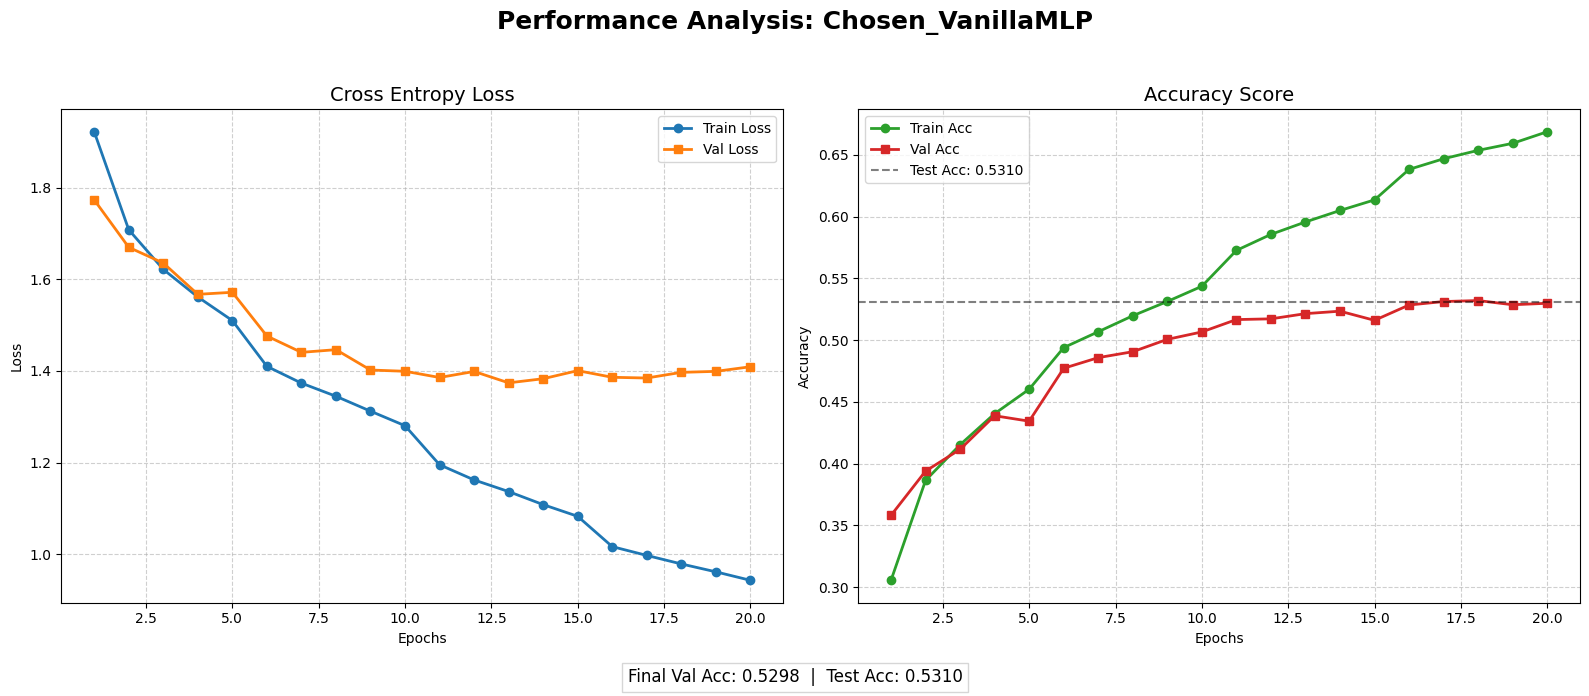

📊 Visualization for Chosen_VanillaMLP saved to: /home/raveco/deep_learning_ass1/outputs/Chosen_VanillaMLP_performance.png


In [18]:
def plot_training_results(results_dict, exp_name=None):
    """
    Plots results. If exp_name is None, it automatically picks the last trained model.
    """
    # 1. Automatic "Latest" Detection
    if exp_name is None:
        # Get the last key added to the dictionary
        exp_name = list(results_dict.keys())[-1]
    
    data = results_dict[exp_name]
    history = data['history']
    epochs = range(1, len(history['train_loss']) + 1)
    
    # 2. Set up the figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f'Performance Analysis: {exp_name}', fontsize=18, fontweight='bold')

    # --- Plot (a): Loss (Training vs Validation) ---
    ax1.plot(epochs, history['train_loss'], 'o-', label='Train Loss', color='#1f77b4', linewidth=2)
    ax1.plot(epochs, history['val_loss'], 's-', label='Val Loss', color='#ff7f0e', linewidth=2)
    ax1.set_title('Cross Entropy Loss', fontsize=14)
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)

    # --- Plot (b): Accuracy (Training vs Validation) ---
    ax2.plot(epochs, history['train_acc'], 'o-', label='Train Acc', color='#2ca02c', linewidth=2)
    ax2.plot(epochs, history['val_acc'], 's-', label='Val Acc', color='#d62728', linewidth=2)
    ax2.set_title('Accuracy Score', fontsize=14)
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    
    # Optional: Plot the Test Accuracy as a horizontal dashed line if it exists
    if 'test_acc' in data:
        ax2.axhline(y=data['test_acc'], color='black', linestyle='--', alpha=0.5, label=f"Test Acc: {data['test_acc']:.4f}")
    
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)

    # 3. Add a "Metadata" footer with the Final Results
    final_txt = (f"Final Val Acc: {history['val_acc'][-1]:.4f}  |  "
                 f"Test Acc: {data.get('test_acc', 'N/A'):.4f}")
    fig.text(0.5, 0.02, final_txt, ha='center', fontsize=12, 
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='#CCCCCC'))

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    
    # 4. Save to outputs
    save_path = Path(OUTPUTS_DIR) / f"{exp_name}_performance.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"📊 Visualization for {exp_name} saved to: {save_path}")

# --- Example Usage ---
# This will automatically find "Chosen_VanillaMLP" if it was the last thing you ran!
plot_training_results(results_log)

In [19]:
def evaluate_model_on_test(results_log, test_dataset, model_name="Chosen_VanillaMLP", device="cuda"):
    """
    Loads a specific model's weights and evaluates it on the test set.
    """
    # 1. Check if model exists in logs
    if model_name not in results_log:
        print(f"Error: {model_name} not found in results_log. Available: {list(results_log.keys())}")
        return None, None
    
    exp_data = results_log[model_name]
    config = exp_data['config']
    weights_path = exp_data.get('model_path')

    print(f"\n--- Evaluating Model: {model_name} on Test Set ---")
    print(f"Config: {config}")

    # 2. Prepare Data Loader
    test_loader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False)
    
    # 3. Re-instantiate Architecture
    model = VanillaMLP(
        hidden_dims=config['hidden_dims'], 
        activation_name=config.get('activation', 'relu')
    ).to(device)
    
    # 4. LOAD SAVED WEIGHTS (The "Brain")
    if weights_path and Path(weights_path).exists():
        model.load_state_dict(torch.load(weights_path, map_location=device))
        print(f"Successfully loaded weights from: {weights_path}")
    else:
        print("⚠️ Warning: No weights file found! Evaluation will be on a randomized model.")

    loss_fn = nn.CrossEntropyLoss()
    model.eval()
    
    test_loss = 0.0
    correct = 0
    total = 0
    
    # 5. Evaluation Loop
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            
            test_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
    final_loss = test_loss / total
    final_acc = correct / total
    
    print("-" * 35)
    print(f"FINAL TEST METRICS for {model_name}:")
    print(f"i.  Accuracy: {final_acc:.4f} ({final_acc*100:.2f}%)")
    print(f"ii. Loss:     {final_loss:.4f}")
    print("-" * 35)

    return final_acc, final_loss


# 1. Evaluate the new Chosen model
chosen_acc, chosen_loss = evaluate_model_on_test(results_log, test_dataset, "Chosen_VanillaMLP")



--- Evaluating Model: Chosen_VanillaMLP on Test Set ---
Config: {'name': 'Chosen_VanillaMLP', 'hidden_dims': [1024, 512, 256, 128], 'lr': 0.001, 'batch_size': 64, 'activation': 'relu', 'optimizer': 'adam', 'init': 'kaiming', 'scheduler': 'step', 'epochs': 20}
Successfully loaded weights from: outputs/models/Chosen_VanillaMLP_weights.pth


-----------------------------------
FINAL TEST METRICS for Chosen_VanillaMLP:
i.  Accuracy: 0.5310 (53.10%)
ii. Loss:     1.4004
-----------------------------------


ImprovedMLP


In [20]:
# 1. Calculate stats from the already loaded train_dataset
# We use a temporary loader to iterate through the data
temp_loader = DataLoader(train_dataset, batch_size=1024, shuffle=False)

mean = 0.0
std = 0.0
for images, _ in temp_loader:
    # images: [batch, 3, 32, 32]
    batch_samples = images.size(0)
    images = images.view(batch_samples, images.size(1), -1)
    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)

mean /= len(train_dataset)
std /= len(train_dataset)

print(f"Computed Mean: {mean.tolist()}")
print(f"Computed Std: {std.tolist()}")

# 2. Define the new transforms using computed stats
train_transform_improved = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transform_improved = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Re-running your specific function with the new logic
train_dataset, val_dataset, test_dataset = get_train_val_test_data(
    train_transforms=train_transform_improved,
    test_transforms=test_transform_improved
)

# Re-create loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


print("✅ Data re-loaded with improved transforms and normalization.")

Computed Mean: [0.4913497269153595, 0.48205819725990295, 0.4464096426963806]
Computed Std: [0.20243243873119354, 0.19957149028778076, 0.20107577741146088]


/home/raveco/.conda/envs/neuro_dl/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


✅ Data re-loaded with improved transforms and normalization.


In [21]:
class ImprovedMLP(nn.Module):
    def __init__(self, input_size=3*32*32, num_class=10, dropout_p=0.15, use_batchnorm=True, act_type="relu"):
        super(ImprovedMLP, self).__init__()
        
        # Consistent with your "Deep" experiment
        dims = [input_size, 1024, 512, 256, 128]
        layers = []
        
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(dims[i+1]))
            
            if act_type == "gelu":
                layers.append(nn.GELU())
            elif act_type == "leaky_relu":
                layers.append(nn.LeakyReLU(0.01))
            else:
                layers.append(nn.ReLU())
            
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
        
        self.network = nn.Sequential(*layers)
        self.output_layer = nn.Linear(dims[-1], num_class)
        
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.output_layer(self.network(x))

In [22]:
# --- 1. Setup Directories & Data ---
IMP_MODEL_SAVE_DIR = Path("outputs/improved/models")
IMP_MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)
IMP_RESULTS_FILE = "improved_mlp_results.pkl"

# Get datasets
train_dataset_aug, val_dataset, test_dataset = get_train_val_test_data(
    train_transforms=train_transform_improved, 
    test_transforms=test_transform_improved
)
train_dataset_clean, _, _ = get_train_val_test_data(
    train_transforms=test_transform_improved, 
    test_transforms=test_transform_improved
)

# Load existing results
try:
    with open(IMP_RESULTS_FILE, "rb") as f:
        improved_log = pickle.load(f)
    print(f"✅ Loaded existing results. skipping {len(improved_log)} experiments.")
except FileNotFoundError:
    improved_log = {}
    print("info: No existing results found.")

# --- 2. Define Experiment Configurations (Including Pairs) ---
imp_experiments = [
    # Single Changes (Originals)
    {"name": "Imp_Only_InputNorm", "bn": False, "drop": 0.0, "aug": False},
    {"name": "Imp_BatchNorm",     "bn": True,  "drop": 0.0, "aug": False},
    {"name": "Imp_Augmentation",  "bn": False, "drop": 0.0, "aug": True},
    
    # Pairs
    {"name": "Imp_BN_and_Aug",    "bn": True,  "drop": 0.0, "aug": True},
    {"name": "Imp_BN_and_Drop",   "bn": True,  "drop": 0.2, "aug": False},
    {"name": "Imp_Aug_and_Drop",  "bn": False, "drop": 0.2, "aug": True},
    
    # Full Combo (Original)
    {"name": "Imp_Full_Combo",    "bn": True,  "drop": 0.2, "aug": True},
]

# --- 3. Run Ablation Study Loop ---
for config in imp_experiments:
    # SKIP logic - handles existing files perfectly
    if config['name'] in improved_log:
        print(f"⏩ Skipping {config['name']} (already done).")
        continue

    print(f"\n🚀 Starting Training for: {config['name']}...")
    
    gc.collect()
    torch.cuda.empty_cache()

    # Loader selection
    current_train_loader = DataLoader(
        train_dataset_aug if config['aug'] else train_dataset_clean, 
        batch_size=64, shuffle=True, num_workers=0
    )
    current_val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)

    # Initialize Model
    model = ImprovedMLP(
        dropout_p=config['drop'], 
        use_batchnorm=config['bn']
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    loss_fn = nn.CrossEntropyLoss()

    # Training
    history = train(
        model=model, optimizer=optimizer, loss_fn=loss_fn,
        train_loader=current_train_loader, val_loader=current_val_loader,
        epochs=15, device=device, scheduler=scheduler
    )

    # Final Test Evaluation
    model.eval()
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)
    test_correct, test_total, test_running_loss = 0, 0, 0.0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            test_running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            test_total += targets.size(0)
            test_correct += predicted.eq(targets).sum().item()

    test_acc = test_correct / test_total
    test_loss = test_running_loss / test_total

    # Save Weights & Log
    model_path = IMP_MODEL_SAVE_DIR / f"{config['name']}_weights.pth"
    torch.save(model.state_dict(), model_path)

    improved_log[config['name']] = {
        "history": history,
        "config": config,
        "test_acc": test_acc,
        "test_loss": test_loss,
        "model_path": str(model_path)
    }

    # Save to pickle immediately
    with open(IMP_RESULTS_FILE, "wb") as f:
        pickle.dump(improved_log, f)

    print(f"✅ {config['name']} Done! Test Acc: {test_acc:.4f}")

print("\n🎉 Ablation study complete!")

✅ Loaded existing results. skipping 7 experiments.
⏩ Skipping Imp_Only_InputNorm (already done).
⏩ Skipping Imp_BatchNorm (already done).
⏩ Skipping Imp_Augmentation (already done).
⏩ Skipping Imp_BN_and_Aug (already done).
⏩ Skipping Imp_BN_and_Drop (already done).
⏩ Skipping Imp_Aug_and_Drop (already done).
⏩ Skipping Imp_Full_Combo (already done).

🎉 Ablation study complete!


In [23]:
# --- 1. Setup & Persistence ---
ULTRA_SAVE_DIR = Path("outputs/improved/ultra")
ULTRA_SAVE_DIR.mkdir(parents=True, exist_ok=True)
ULTRA_RESULTS_FILE = "ultra_mlp_results.pkl"

# Load existing results
try:
    with open(ULTRA_RESULTS_FILE, "rb") as f:
        ultra_log = pickle.load(f)
    print(f"✅ Loaded existing ultra results.")
except FileNotFoundError:
    ultra_log = {}

# --- 2. Configuration ---
ultra_config = {
    "name": "Ultra_MLP_Final_Push",
    "hidden_dims": [1024, 512, 256, 128],
    "lr": 0.001,
    "batch_size": 128, # Larger batch size for more stable BN gradients
    "epochs": 50,      # Increased epochs for convergence
    "dropout": 0.25,   # Slightly higher to combat overfitting over 50 epochs
    "use_bn": True
}

# SKIP LOGIC
if ultra_config['name'] in ultra_log:
    print(f"⏩ Skipping {ultra_config['name']}: Already completed with Test Acc: {ultra_log[ultra_config['name']]['test_acc']:.4f}")
else:
    print(f"🚀 Starting High-Performance Trial: {ultra_config['name']}...")
    
    # --- 3. Data Preparation ---
    # Using the same datasets you initialized earlier
    # Ensure train_dataset uses the augmented transforms
    train_loader = DataLoader(train_dataset, batch_size=ultra_config['batch_size'], shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=ultra_config['batch_size'], shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=ultra_config['batch_size'], shuffle=False, num_workers=0)

    # --- 4. Initialization ---
    gc.collect()
    torch.cuda.empty_cache()

    model = ImprovedMLP(
        dropout_p=ultra_config['dropout'], 
        use_batchnorm=ultra_config['use_bn']
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=ultra_config['lr'], weight_decay=1e-4)
    
    # Cosine Annealing is often better for final accuracy than StepLR
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=ultra_config['epochs'])
    loss_fn = torch.nn.CrossEntropyLoss()

    # --- 5. Training ---
    history = train(
        model=model, 
        optimizer=optimizer, 
        loss_fn=loss_fn,
        train_loader=train_loader, 
        val_loader=val_loader,
        epochs=ultra_config['epochs'], 
        device=device,
        scheduler=scheduler
    )

    # --- 6. Final Evaluation ---
    model.eval()
    test_correct, test_total, test_running_loss = 0, 0, 0.0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            test_running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            test_total += targets.size(0)
            test_correct += predicted.eq(targets).sum().item()

    test_acc = test_correct / test_total
    test_loss = test_running_loss / test_total

    # --- 7. Save Everything ---
    model_path = ULTRA_SAVE_DIR / f"{ultra_config['name']}_weights.pth"
    torch.save(model.state_dict(), model_path)

    ultra_log[ultra_config['name']] = {
        "history": history,
        "config": ultra_config,
        "test_acc": test_acc,
        "test_loss": test_loss,
        "model_path": str(model_path)
    }

    with open(ULTRA_RESULTS_FILE, "wb") as f:
        pickle.dump(ultra_log, f)

    print(f"🎯 Final Achievement! Test Acc: {test_acc:.4f}")

✅ Loaded existing ultra results.
⏩ Skipping Ultra_MLP_Final_Push: Already completed with Test Acc: 0.5956


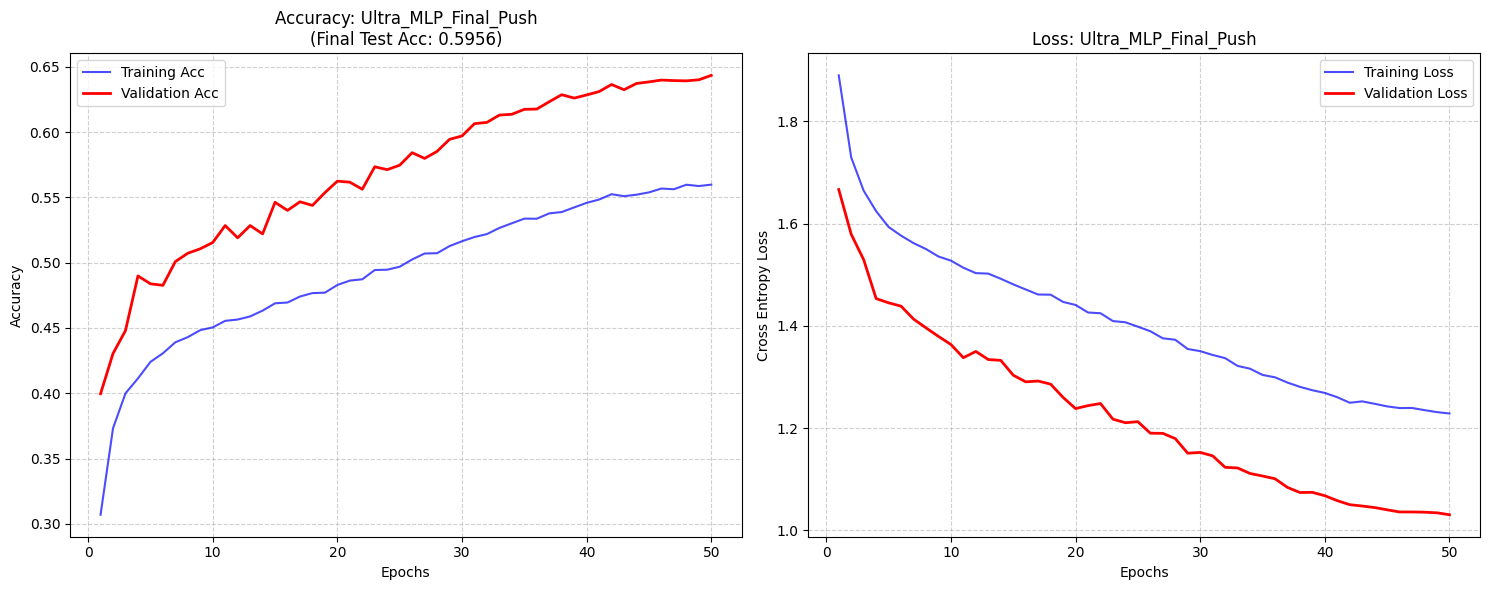

📈 Plot saved to: outputs/improved/ultra_performance_curves.png


In [24]:
# 1. Load the results
with open("ultra_mlp_results.pkl", "rb") as f:
    ultra_log = pickle.load(f)

# Get the specific experiment data
exp_name = "Ultra_MLP_Final_Push"
data = ultra_log[exp_name]
history = data['history']
epochs = range(1, len(history['train_acc']) + 1)

# 2. Create the plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Accuracy
ax1.plot(epochs, history['train_acc'], 'b-', label='Training Acc', alpha=0.7)
ax1.plot(epochs, history['val_acc'], 'r-', label='Validation Acc', linewidth=2)
ax1.set_title(f'Accuracy: {exp_name}\n(Final Test Acc: {data["test_acc"]:.4f})')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Loss
ax2.plot(epochs, history['train_loss'], 'b-', label='Training Loss', alpha=0.7)
ax2.plot(epochs, history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
ax2.set_title(f'Loss: {exp_name}')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Cross Entropy Loss')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("outputs/improved/ultra_performance_curves.png")
plt.show()

print(f"📈 Plot saved to: outputs/improved/ultra_performance_curves.png")

In [27]:
# --- 1. Setup & Persistence ---
ULTRA_SAVE_DIR = Path("outputs/improved/ultra")
ULTRA_SAVE_DIR.mkdir(parents=True, exist_ok=True)
ULTRA_RESULTS_FILE = "ultra_mlp_results.pkl"

try:
    with open(ULTRA_RESULTS_FILE, "rb") as f:
        ultra_log = pickle.load(f)
except FileNotFoundError:
    ultra_log = {}

# --- 2. Define the Variants ---
ultra_variants = [
    {"name": "Ultra_LeakyReLU", "act": "leaky_relu", "epochs": 50, "dropout": 0.2},
    {"name": "Ultra_GeLU",      "act": "gelu",       "epochs": 50, "dropout": 0.2}
]

for config in ultra_variants:
    if config['name'] in ultra_log:
        print(f"⏩ Skipping {config['name']} (already done).")
        continue

    print(f"\n🚀 Starting High-Performance Trial: {config['name']}...")
    
    gc.collect()
    torch.cuda.empty_cache()

    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=0)

    # 3. Model Instantiation
    model = ImprovedMLP(
        dropout_p=config['dropout'], 
        use_batchnorm=True
    ).to(device)

    # --- FIXED INJECTION LOGIC ---
    # We use list() to prevent "RuntimeError: dictionary changed size during iteration"
    for name, module in list(model.named_modules()):
        # Check if the module is part of a Sequential block (common in MLPs)
        if hasattr(module, '_modules'):
            for sub_name, sub_module in list(module._modules.items()):
                if isinstance(sub_module, nn.ReLU):
                    if config['act'] == 'leaky_relu':
                        module._modules[sub_name] = nn.LeakyReLU(0.1)
                    elif config['act'] == 'gelu':
                        module._modules[sub_name] = nn.GELU()
        
        # Check top-level attributes
        if isinstance(module, nn.ReLU):
            # This handles cases where ReLU is a direct attribute
            parent_name = name.rsplit('.', 1)
            if len(parent_name) > 1:
                parent = dict(model.named_modules())[parent_name[0]]
                setattr(parent, parent_name[1], nn.LeakyReLU(0.1) if config['act'] == 'leaky_relu' else nn.GELU())
            else:
                setattr(model, name, nn.LeakyReLU(0.1) if config['act'] == 'leaky_relu' else nn.GELU())

    # 4. Optimization Strategy
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['epochs'])
    loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

    # 5. Training
    history = train(
        model=model, optimizer=optimizer, loss_fn=loss_fn,
        train_loader=train_loader, val_loader=val_loader,
        epochs=config['epochs'], device=device, scheduler=scheduler
    )

    # 6. Evaluation
    model.eval()
    test_correct, test_total = 0, 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            test_total += targets.size(0)
            test_correct += predicted.eq(targets).sum().item()

    test_acc = test_correct / test_total

    # 7. Final Save
    model_path = ULTRA_SAVE_DIR / f"{config['name']}_weights.pth"
    torch.save(model.state_dict(), model_path)

    ultra_log[config['name']] = {
        "history": history,
        "config": config,
        "test_acc": test_acc,
        "model_path": str(model_path)
    }

    with open(ULTRA_RESULTS_FILE, "wb") as f:
        pickle.dump(ultra_log, f)

    print(f"🎯 Achievement Unlocked: {config['name']} | Test Acc: {test_acc:.4f}")

print("\n✅ All Ultra experiments completed without iteration errors.")


🚀 Starting High-Performance Trial: Ultra_LeakyReLU...
🎯 Achievement Unlocked: Ultra_LeakyReLU | Test Acc: 0.6024

🚀 Starting High-Performance Trial: Ultra_GeLU...
🎯 Achievement Unlocked: Ultra_GeLU | Test Acc: 0.6232

✅ All Ultra experiments completed without iteration errors.


## End of Notebook

All data analysis and visualization cells have been executed. 

- **Inline plots**: All plots are displayed inline in the notebook using `%matplotlib inline`.
- **Saved outputs**: All plots are also saved to the `outputs/` folder with descriptive filenames.
- **Training & testing**: The `train()` and `test()` functions are ready to use with your model definitions.
- **Model templates**: Uncomment and implement the `VanillaMLP` and `ImprovedMLP` classes as needed.